[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ddumu/dourado-minguell-eml-mia-um-p1/blob/main/k_brazos/epsilon_greedy_bernoulli_dist_experiment.ipynb)

# Estudio del bandido de k-brazos mediante el algoritmo $\epsilon$-Greedy con distribución de Bernoulli

En este notebook se ejecuta y comenta la ejecución del experimento del bandido de k-brazos mediante el algoritmo $\epsilon$-greedy con brazos cuya recompensa viene dada por una función de distribución de Bernoulli.

In [ ]:
!git clone https://github.com/ddumu/dourado-minguell-eml-mia-um-p1
%cd dourado-minguell-eml-mia-um-p1/k_brazos/
%ls

## Constantes

In [ ]:
SEED = 42

K = 10
RUNS = 1000
STEPS = 20_000

SAVE_PLOTS_PATH = "plots/epsilon_greedy_bernoulli_dist"

## Librerías

In [ ]:
import sys
import random

import numpy as np
from typing import List

sys.path.append('./src')
print(sys.path)

from arms import ArmBernoulli, Bandit
from experiment import run_experiment
from algorithms import Algorithm, EpsilonGreedy
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

['C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\python312.zip', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\DLLs', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none', 'C:\\Users\\Usuario\\Documents\\UM-MIA\\EML\\dourado-minguell-eml-mia-um-p1\\.venv', '', 'C:\\Users\\Usuario\\Documents\\UM-MIA\\EML\\dourado-minguell-eml-mia-um-p1\\.venv\\Lib\\site-packages', './src']


## Reproducibilidad

In [ ]:
random.seed(SEED)
np.random.seed(SEED)

Asegurar que la generación de números aleatorios es igual para todos los experimentos.

## Experimentación

Se ejecuta la experimentación del problema del bandido de k-brazos durante el número de pasos y ejecuciones definido en las constantes. Posteriormente, se realiza el pertienente estudio de resultados mediantes las gráficas de recompensas promedio, selecciones óptimas, arrepentimiento y estadísticas por brazo.

In [ ]:
# Creación del bandido de k-brazos
bandit = Bandit(arms=ArmBernoulli.generate_arms(K))
optimal_arm = bandit.optimal_arm

print(bandit)
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

Bandit with 10 arms: ArmBernoulli (np=0.37), ArmBernoulli (np=0.95), ArmBernoulli (np=0.6), ArmBernoulli (np=0.73), ArmBernoulli (np=0.16), ArmBernoulli (np=0.06), ArmBernoulli (np=0.87), ArmBernoulli (np=0.71), ArmBernoulli (np=0.97), ArmBernoulli (np=0.02)
Optimal arm: 9 with expected reward=0.97


Para le experimentación, se va emplear un bandido de 10 brazos. Para este caso reproducible, el brazo óptimo es el número 9 con una recompensa media esperada de 0.97. Se van a comparar los resultados con distintos valores para epsilon:
 - $\epsilon = 0.0$
 - $\epsilon = 0.01$
 - $\epsilon = 0.1$
 - $\epsilon = 0.5$

In [ ]:
# Definir los algoritmos greedy con diferente epsilon
algorithms_greedy = [
    EpsilonGreedy(k=K, epsilon=0),
    EpsilonGreedy(k=K, epsilon=0.01),
    EpsilonGreedy(k=K, epsilon=0.1),
    EpsilonGreedy(k=K, epsilon=0.5)
]

# Ejecutar el experimento
rewards_greedy, optimal_selections_greedy, regret_accumulated_greedy, arm_stats_greedy = run_experiment(bandit, algorithms_greedy, STEPS, RUNS)

Ya se han definido los algoritmos y ejecutada la experimentación. A continuación, se van a comentar los resultados obetnidos mediante las correspondientes gráficas.

#### Recompensas promedio

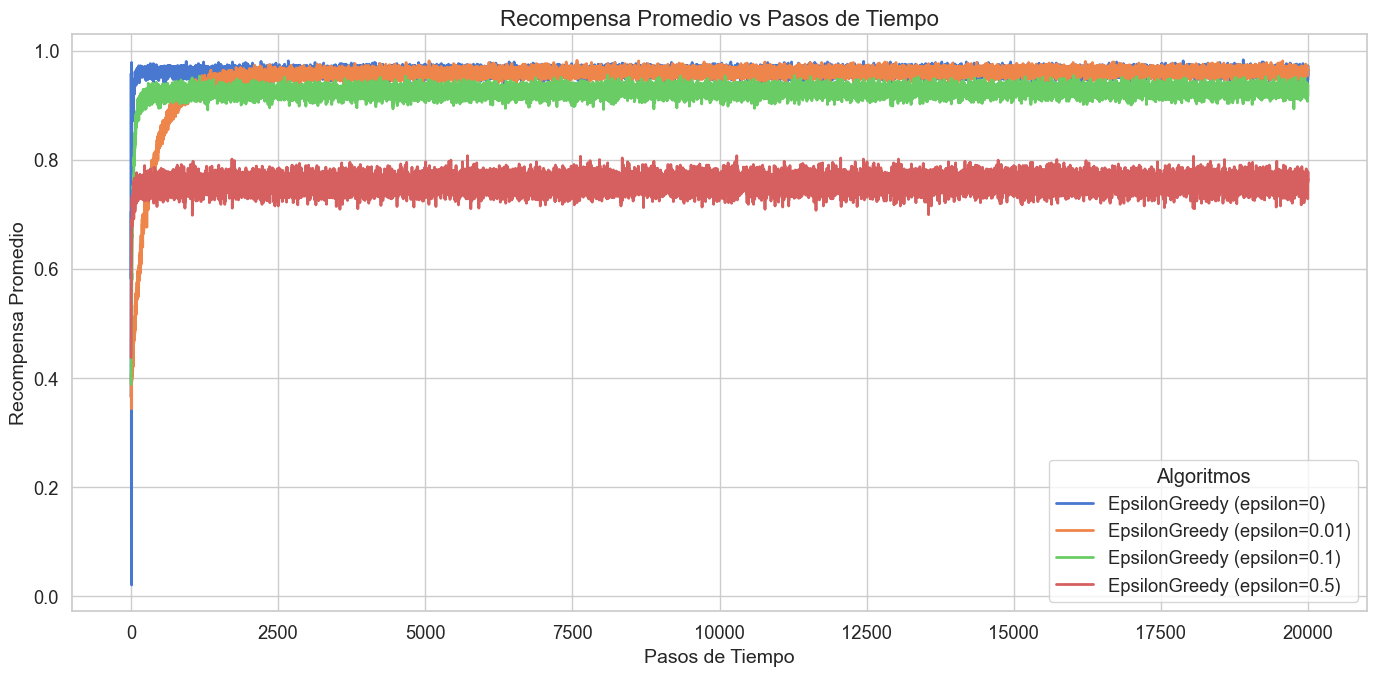

In [ ]:
plot_average_rewards(STEPS, rewards_greedy, algorithms_greedy, SAVE_PLOTS_PATH)

En el caso de la distribución de Bernoulli, comprobamos que ocurre lo mismo que para el caso de la binomial. La variante epsilon=0 y epsilon=0.01 son las que mejor recompensas promedio obtienen. Para este caso epsilon=0.1 se acerca más, pero está claramente diferenciado.

#### Selecciones óptimas

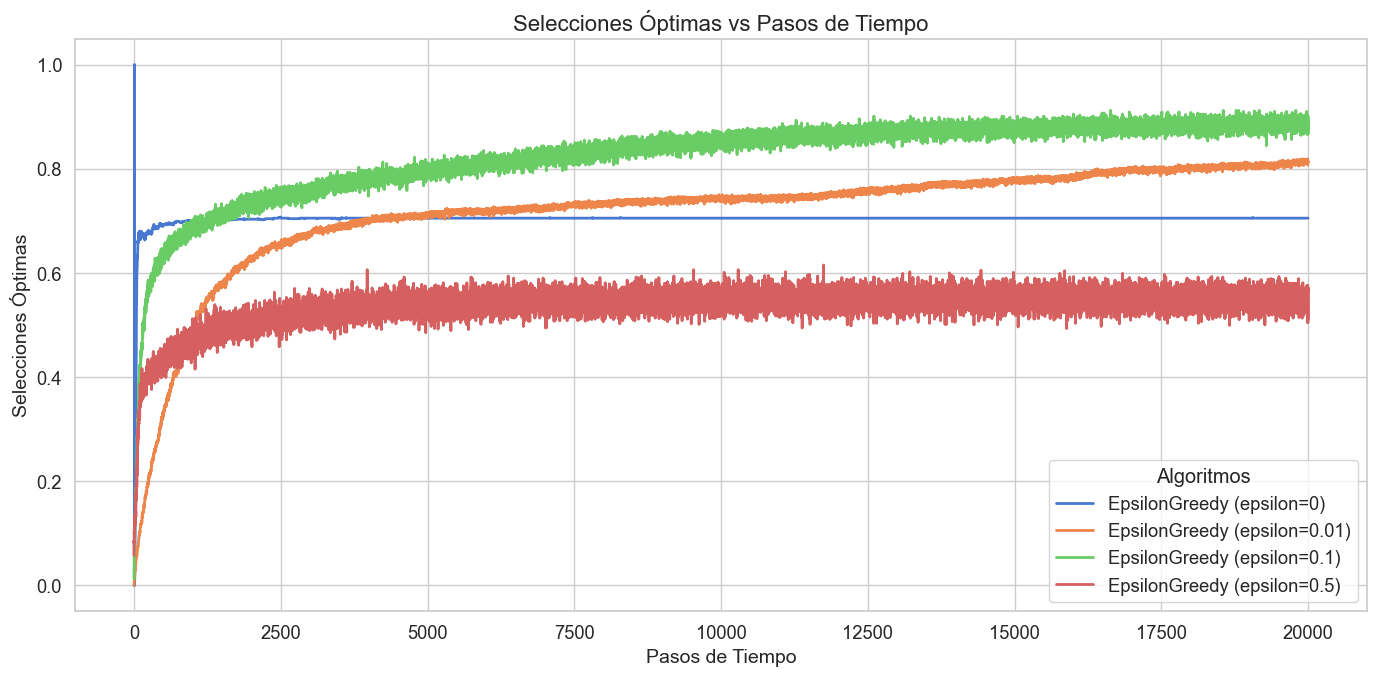

In [ ]:
plot_optimal_selections(STEPS, optimal_selections_greedy, algorithms_greedy, SAVE_PLOTS_PATH)

En cuanto al número de selecciones óptimas, cómo en casos anteriores, el algoritmo puramente explotador mantiene una media entre ejecuciones constante y por debajo de lo óptimo. En comparación con la distribucional binomial con n=100 donde, en los mismos pasos de tiempo, el algoritmo con epsilon=0.01 superaba al de epsilon=0.1, para este caso particular de la binomial donde n=1, todavía necesita más pasos para superarlo aunque sí se aprecia la tendencia para ello.

#### Arrepentimiento

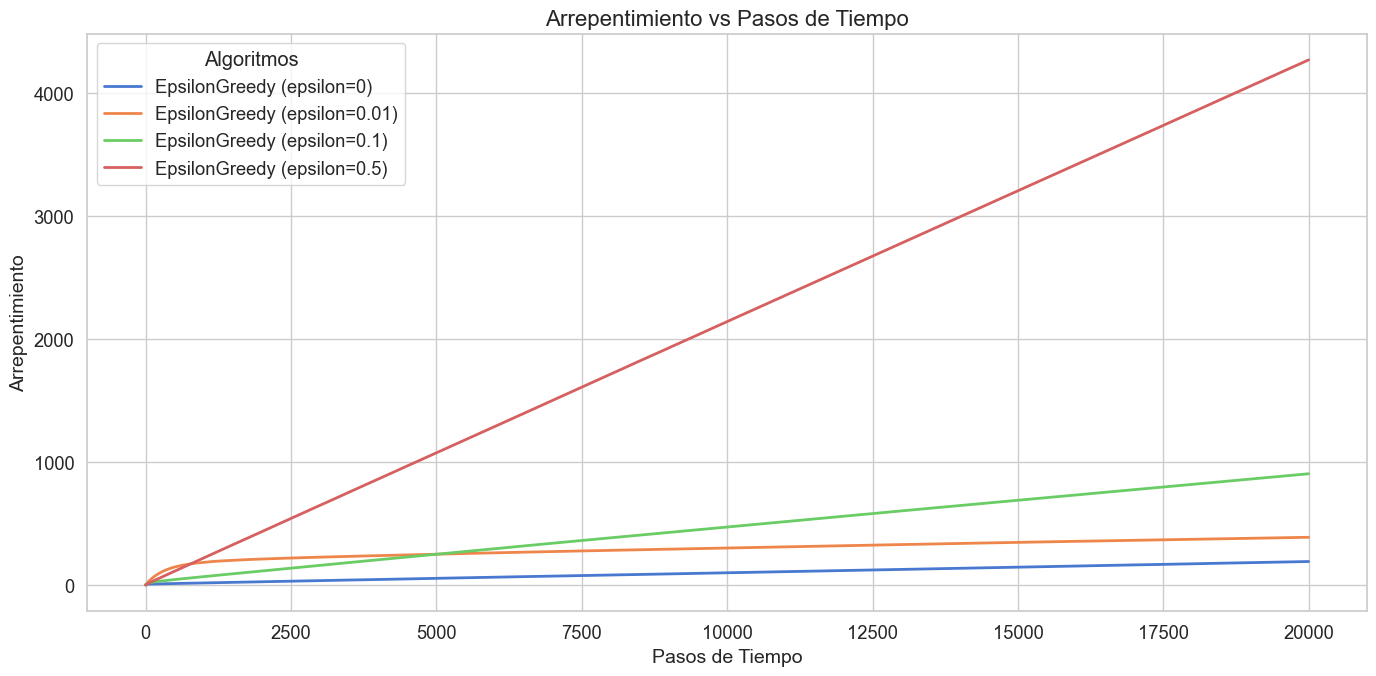

In [ ]:
plot_regret(STEPS, regret_accumulated_greedy, algorithms_greedy, SAVE_PLOTS_PATH)

El arrepentimiento acumualdo confirma lo que se ha estado viendo hasta el momento, demasiada exploración con epsilon=0.5 y epsilon=0.1 accarea mucho arrepentimiento. La tendenencia de las dos versiones restantes indica que en un mayor número de pasos, las líneas se cruzarán y la variante con epsilon=0.01 será la que menos arrepentimiento haya acumulado.

#### Estadísticas por brazo

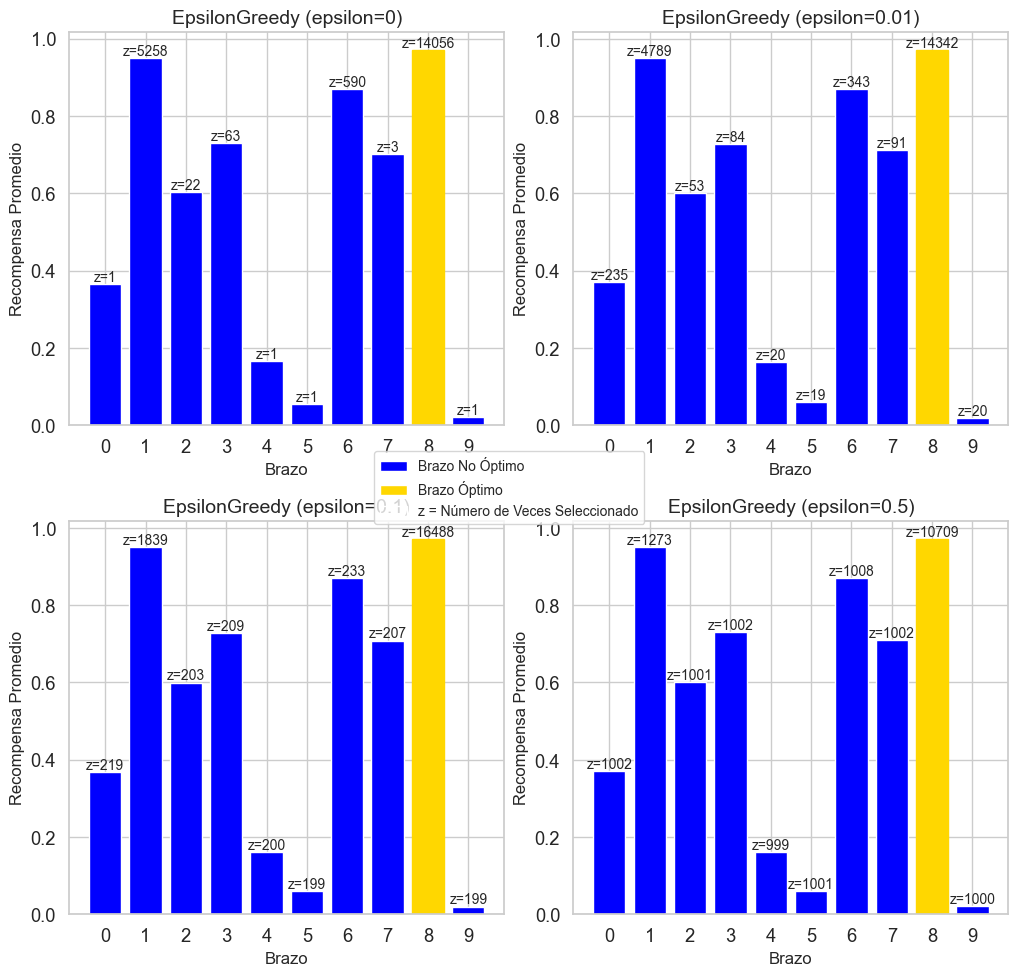

In [ ]:
plot_arm_statistics(arm_stats_greedy, algorithms_greedy, SAVE_PLOTS_PATH)

Las estadísticas por brazo nos permiten ver que estamos en un escenario similar al que nos hemos encontrado con la distribución binomial. Hay dos brazos con probabilidades de éxito casi iguales y un tercero cercano lo que potencia los resultados de los algoritmos explotadores a corto plazo.

## Conclusiones

En este experimento se han obtenido resultados similares a los obtenidos bajo la distribución binomial. Al tener los dos brazos con mejor recompensa una tan similar, el algoritmo explotador tiene mayor probabilidad de elegir un brazo igual o muy cercano al óptimo en la primera y única selección. Esto hace que en pocos pasos, en el promedio de muchas ejecuciones, sea igual de bueno o mejor que un algoritmo explorador. Si se deja durante más tiempo, como se han visto en las gráficas, el algoritmo con una exploración controlada termina acumulando menos arrepentimiento y seleccionado el brazo óptimo en un porcentaje mayor.